# 🚀 Foundr.AI — Startup Success & Failure Prediction Model
### Comprehensive EDA, Feature Engineering & Machine Learning Pipeline
**Dataset:** Real-world Crunchbase Dataset (`Data/big_startup_secsees_dataset.csv`)

---
### 📌 Objective:
Train, evaluate, and benchmark multiple Machine Learning classification algorithms to predict whether a startup achieves a **successful outcome (Acquired / IPO)** versus **failure (Closed)** based on investment, category, geographical, and operational metrics.


In [1]:
import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
%matplotlib inline

print("✅ All required libraries imported successfully.")


✅ All required libraries imported successfully.


---
## 1. 📂 Data Loading & Initial Exploration


In [2]:
data_path = Path("Data/big_startup_secsees_dataset.csv")
df_raw = pd.read_csv(data_path)

print(f"📊 Dataset Shape: {df_raw.shape[0]:,} rows, {df_raw.shape[1]} columns\n")
print("First 5 rows:")
df_raw.head()


📊 Dataset Shape: 66,368 rows, 14 columns

First 5 rows:


,permalink,name,homepage_url,category_list,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,founded_at,first_funding_at,last_funding_at
0,/organization/-fame,#fame,http://livfame.com,Media,10000000,operating,IND,16,Mumbai,Mumbai,1,NaN,2015-01-05,2015-01-05
1,/organization/-qounter,:Qounter,http://www.qounter.com,Application Platforms|Real Time|Social Network...,700000,operating,USA,DE,DE - Other,Delaware City,2,2014-09-04,2014-03-01,2014-10-14
2,/organization/-the-one-of-them-inc-,"(THE) ONE of THEM,Inc.",http://oneofthem.jp,Apps|Games|Mobile,3406878,operating,NaN,NaN,NaN,NaN,1,NaN,2014-01-30,2014-01-30
3,/organization/0-6-com,0-6.com,http://www.0-6.com,Curated Web,2000000,operating,CHN,22,Beijing,Beijing,1,2007-01-01,2008-03-19,2008-03-19
4,/organization/004-technologies,004 Technologies,http://004gmbh.de/en/004-interact,Software,-,operating,USA,IL,"Springfield, Illinois",Champaign,1,2010-01-01,2014-07-24,2014-07-24


In [3]:
print("📋 Column Information:")
df_raw.info()

print("\n🎯 Status Distribution (Raw Data):")
print(df_raw['status'].value_counts(dropna=False))


📋 Column Information:


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66368 entries, 0 to 66367
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   permalink          66368 non-null  object
 1   name               66367 non-null  object
 2   homepage_url       61310 non-null  object
 3   category_list      63220 non-null  object
 4   funding_total_usd  66368 non-null  object
 5   status             66368 non-null  object
 6   country_code       59410 non-null  object
 7   state_code         57821 non-null  object
 8   region             58338 non-null  object
 9   city               58340 non-null  object
 10  funding_rounds     66368 non-null  int64 
 11  founded_at         51147 non-null  object
 12  first_funding_at   66344 non-null  object
 13  last_funding_at    66368 non-null  object
dtypes: int64(1), object(13)
memory usage: 7.1+ MB

🎯 Status Distribution (Raw Data):
status
operating    53034
closed        6238
acquire

---
## 2. 🧹 Data Cleaning & Preprocessing

### Target Definition:
- **Success (`1`)**: Startups with status `acquired` or `ipo`
- **Failure (`0`)**: Startups with status `closed`
*(Operating companies represent unresolved ongoing ventures and are filtered for definitive outcome classification)*

### Cleaning Steps:
1. Filter dataset to closed, acquired, and ipo outcomes.
2. Clean `funding_total_usd` (strip special characters, convert `-` to NaN, cast to numeric).
3. Parse dates (`founded_at`, `first_funding_at`, `last_funding_at`) to datetime objects.
4. Extract clean primary industry/category from `category_list`.


In [4]:
# Filter terminal outcomes
df_clean = df_raw[df_raw['status'].isin(['closed', 'acquired', 'ipo'])].copy()

# Create binary target
df_clean['success'] = df_clean['status'].apply(lambda s: 1 if s in ['acquired', 'ipo'] else 0)

# Clean funding_total_usd
df_clean['funding_total_usd'] = df_clean['funding_total_usd'].astype(str).str.strip().str.replace(',', '').str.replace('$', '', regex=False)
df_clean['funding_total_usd'] = pd.to_numeric(df_clean['funding_total_usd'], errors='coerce')

# Parse dates
df_clean['founded_at'] = pd.to_datetime(df_clean['founded_at'], errors='coerce')
df_clean['first_funding_at'] = pd.to_datetime(df_clean['first_funding_at'], errors='coerce')
df_clean['last_funding_at'] = pd.to_datetime(df_clean['last_funding_at'], errors='coerce')

# Extract primary category
def extract_primary_cat(val):
    if pd.isna(val):
        return 'Other'
    parts = [p.strip() for p in str(val).split('|') if p.strip()]
    return parts[0] if len(parts) > 0 else 'Other'

df_clean['primary_category'] = df_clean['category_list'].apply(extract_primary_cat)

# Consolidate top categories (top 15 + Other)
top_cats = df_clean['primary_category'].value_counts().nlargest(15).index.tolist()
df_clean['primary_category'] = df_clean['primary_category'].apply(lambda c: c if c in top_cats else 'Other')

# Consolidate top countries (top 10 + Other)
top_countries = df_clean['country_code'].value_counts().nlargest(10).index.tolist()
df_clean['country_clean'] = df_clean['country_code'].apply(lambda c: c if c in top_countries else 'Other')

print(f"Cleaned dataset shape: {df_clean.shape}")
print(f"Target distribution:\n{df_clean['success'].value_counts(normalize=True).round(4) * 100}")


Cleaned dataset shape: (13334, 17)
Target distribution:
success
1    53.22
0    46.78
Name: proportion, dtype: float64


---
## 3. ⚙️ Feature Engineering

We engineer meaningful predictive domain features:
1. **`funding_duration_years`**: Duration between first and last funding rounds.
2. **`age_at_first_funding_years`**: Time from company founding to securing first funding.
3. **`funding_per_round`**: Average capital raised per funding round.
4. **`log_funding_total`**: Log-transformed total funding to handle extreme skew.


In [5]:
# Feature 1: Funding Duration in Years
df_clean['funding_duration_years'] = (df_clean['last_funding_at'] - df_clean['first_funding_at']).dt.days / 365.25
df_clean['funding_duration_years'] = df_clean['funding_duration_years'].clip(lower=0)

# Feature 2: Age at First Funding in Years
df_clean['age_at_first_funding_years'] = (df_clean['first_funding_at'] - df_clean['founded_at']).dt.days / 365.25
df_clean['age_at_first_funding_years'] = df_clean['age_at_first_funding_years'].apply(lambda x: x if (pd.notna(x) and 0 <= x <= 30) else np.nan)

# Feature 3: Funding per Round
df_clean['funding_per_round'] = df_clean['funding_total_usd'] / df_clean['funding_rounds'].replace(0, 1)

# Feature 4: Log-transformed Total Funding
df_clean['log_funding_total'] = np.log1p(df_clean['funding_total_usd'].clip(lower=0))

features_to_inspect = [
    'funding_total_usd', 'funding_rounds', 'funding_duration_years',
    'age_at_first_funding_years', 'funding_per_round', 'log_funding_total'
]
df_clean[features_to_inspect].describe().round(2)


,funding_total_usd,funding_rounds,funding_duration_years,age_at_first_funding_years,funding_per_round,log_funding_total
count,1.114300e+04,13334.00,13332.00,8660.00,1.114300e+04,11143.00
mean,3.580863e+07,1.86,1.21,3.82,1.845922e+07,15.19
std,3.687556e+08,1.52,2.38,5.21,2.057071e+08,2.39
min,2.000000e+00,1.00,0.00,0.00,2.000000e+00,1.10
25%,1.000000e+06,1.00,0.00,0.58,6.822377e+05,13.82
50%,5.800000e+06,1.00,0.00,1.75,3.633333e+06,15.57
75%,2.200000e+07,2.00,1.62,4.84,1.080000e+07,16.91
max,3.007950e+10,18.00,92.07,29.95,1.760000e+10,24.13


---
## 4. 📈 Exploratory Data Analysis & Visualizations


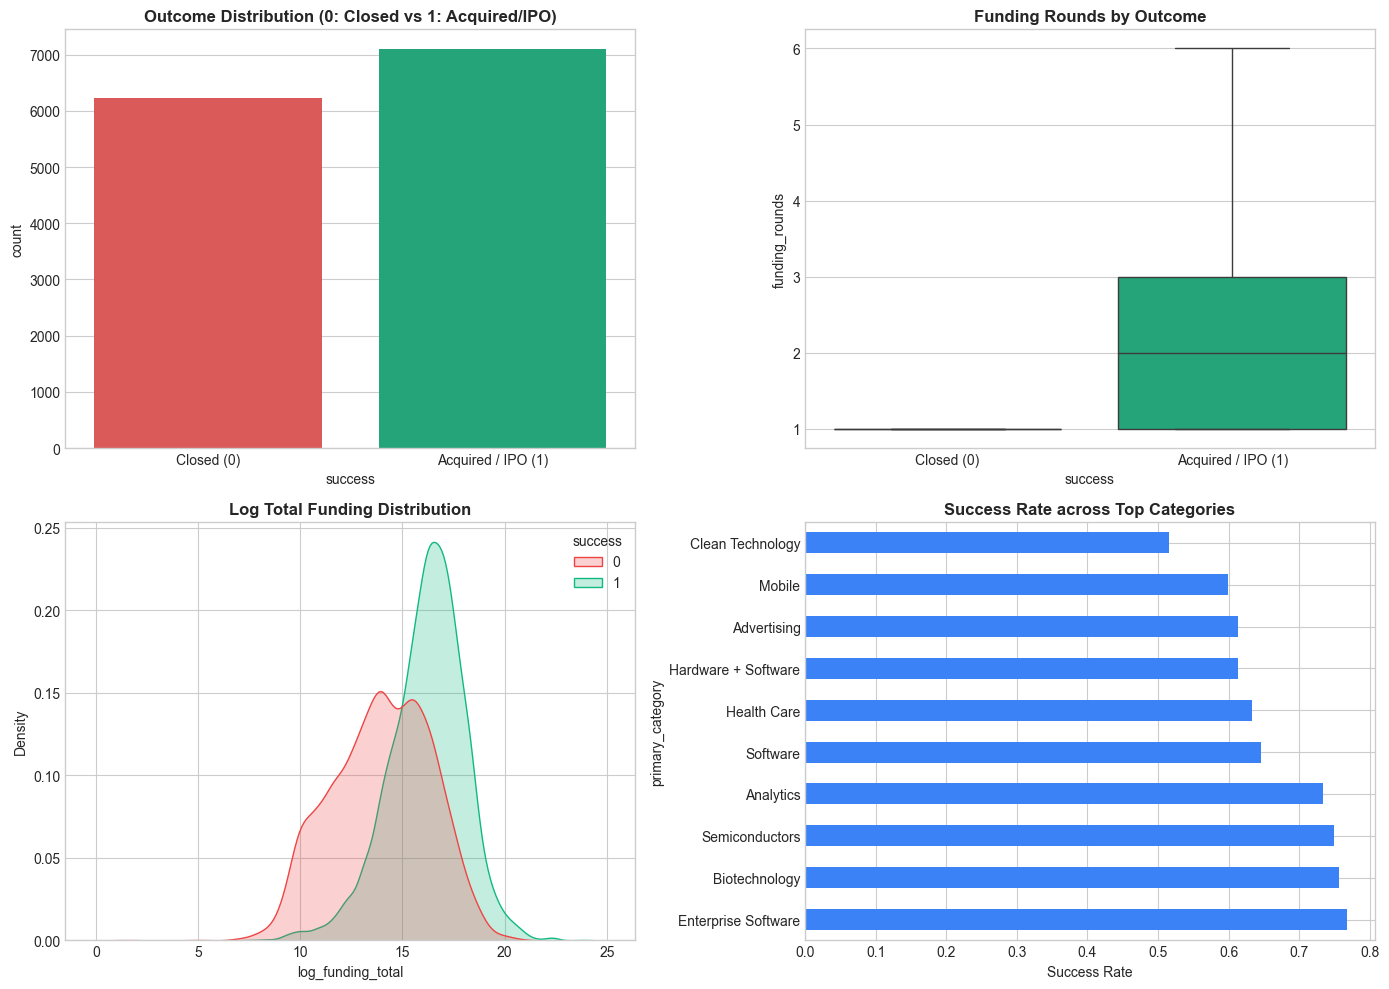

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Target Distribution
sns.countplot(data=df_clean, x='success', ax=axes[0, 0], palette=['#EF4444', '#10B981'])
axes[0, 0].set_title('Outcome Distribution (0: Closed vs 1: Acquired/IPO)', fontsize=12, fontweight='bold')
axes[0, 0].set_xticklabels(['Closed (0)', 'Acquired / IPO (1)'])

# 2. Funding Rounds vs Success
sns.boxplot(data=df_clean, x='success', y='funding_rounds', ax=axes[0, 1], palette=['#EF4444', '#10B981'], showfliers=False)
axes[0, 1].set_title('Funding Rounds by Outcome', fontsize=12, fontweight='bold')
axes[0, 1].set_xticklabels(['Closed (0)', 'Acquired / IPO (1)'])

# 3. Log Total Funding by Outcome
sns.kdeplot(data=df_clean, x='log_funding_total', hue='success', ax=axes[1, 0], common_norm=False, palette=['#EF4444', '#10B981'], fill=True)
axes[1, 0].set_title('Log Total Funding Distribution', fontsize=12, fontweight='bold')

# 4. Success Rate by Top Categories
cat_success = df_clean.groupby('primary_category')['success'].mean().sort_values(ascending=False).head(10)
cat_success.plot(kind='barh', ax=axes[1, 1], color='#3B82F6')
axes[1, 1].set_title('Success Rate across Top Categories', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Success Rate')

plt.tight_layout()
plt.show()


---
## 5. 🤖 Machine Learning Pipeline & Model Training

We construct a robust `ColumnTransformer` with:
- **Numeric Pipeline**: Median Imputation + Standard Scaling
- **Categorical Pipeline**: Most Frequent Imputation + OneHotEncoding (`handle_unknown='ignore'`)

We benchmark 4 distinct algorithms:
1. **Logistic Regression** (L2 Regularized Baseline)
2. **Decision Tree Classifier**
3. **Random Forest Classifier** (Ensemble bagging with balanced class weighting)
4. **Gradient Boosting Classifier** (Ensemble boosting)


In [7]:
NUMERICAL_FEATURES = [
    'funding_total_usd',
    'funding_rounds',
    'funding_duration_years',
    'age_at_first_funding_years',
    'funding_per_round'
]

CATEGORICAL_FEATURES = [
    'primary_category',
    'country_clean'
]

ALL_FEATURES = NUMERICAL_FEATURES + CATEGORICAL_FEATURES
X = df_clean[ALL_FEATURES]
y = df_clean['success']

# Train-Test Split (75% train, 25% test, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]:,} samples")
print(f"Testing set: {X_test.shape[0]:,} samples")

# Build Preprocessor
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, NUMERICAL_FEATURES),
        ('cat', categorical_transformer, CATEGORICAL_FEATURES)
    ]
)

# Define Candidate Models
classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=8, min_samples_leaf=20, class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=250, max_depth=12, min_samples_split=5, class_weight='balanced', random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, learning_rate=0.08, max_depth=5, random_state=42)
}

trained_models = {}
evaluation_results = []

for name, clf in classifiers.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', clf)
    ])
    
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)
    
    trained_models[name] = pipe
    evaluation_results.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4),
        'ROC-AUC': round(roc, 4)
    })

df_results = pd.DataFrame(evaluation_results).sort_values(by=['ROC-AUC', 'F1-Score'], ascending=False)
print("\n📊 Model Benchmark Performance:")
print(df_results.to_string(index=False))


Training set: 10,000 samples
Testing set: 3,334 samples



📊 Model Benchmark Performance:
              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
      Random Forest    0.7442     0.7591  0.7604    0.7598   0.8203
  Gradient Boosting    0.7400     0.7455  0.7762    0.7606   0.8138
      Decision Tree    0.7244     0.7707  0.6860    0.7259   0.8022
Logistic Regression    0.7256     0.7686  0.6928    0.7287   0.7983


---
## 6. 📊 Model Evaluation & Visualization
### ROC-AUC Curves and Confusion Matrix Comparison


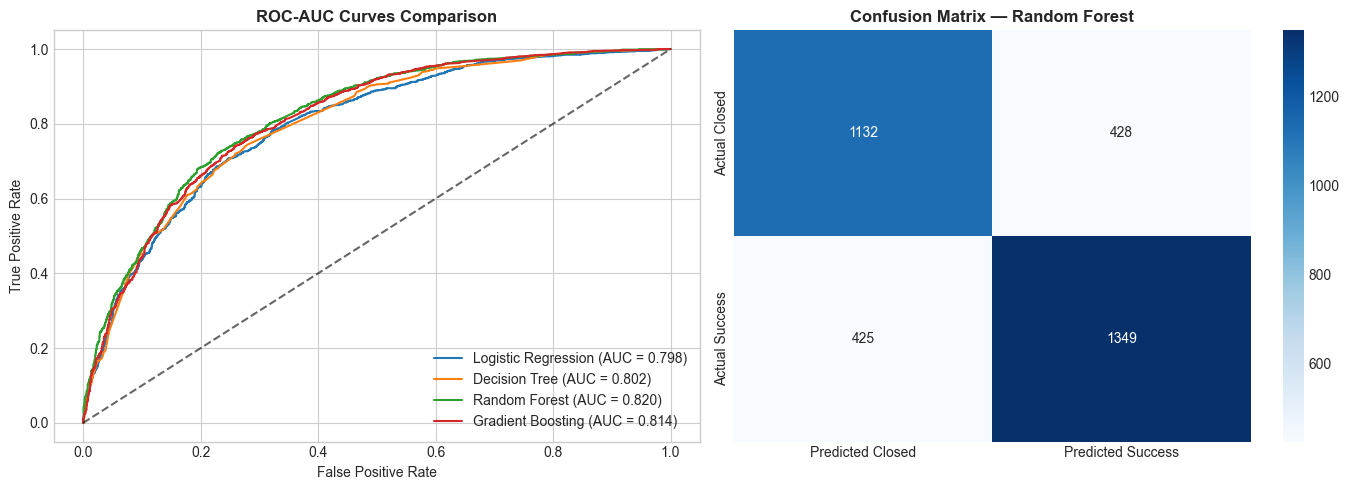


📋 Classification Report for Best Model (Random Forest):

                    precision    recall  f1-score   support

        Closed (0)       0.73      0.73      0.73      1560
Acquired / IPO (1)       0.76      0.76      0.76      1774

          accuracy                           0.74      3334
         macro avg       0.74      0.74      0.74      3334
      weighted avg       0.74      0.74      0.74      3334



In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. ROC-AUC Curves
for name, pipe in trained_models.items():
    y_prob = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    score = roc_auc_score(y_test, y_prob)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC = {score:.3f})")

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.6)
axes[0].set_title('ROC-AUC Curves Comparison', fontsize=12, fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right')

# 2. Confusion Matrix for Best Model (Random Forest)
best_model_name = df_results.iloc[0]['Model']
best_pipe = trained_models[best_model_name]
y_pred_best = best_pipe.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Predicted Closed', 'Predicted Success'],
            yticklabels=['Actual Closed', 'Actual Success'])
axes[1].set_title(f'Confusion Matrix — {best_model_name}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n📋 Classification Report for Best Model ({best_model_name}):\n")
print(classification_report(y_test, y_pred_best, target_names=['Closed (0)', 'Acquired / IPO (1)']))


---
## 7. 🔍 Feature Importance Analysis


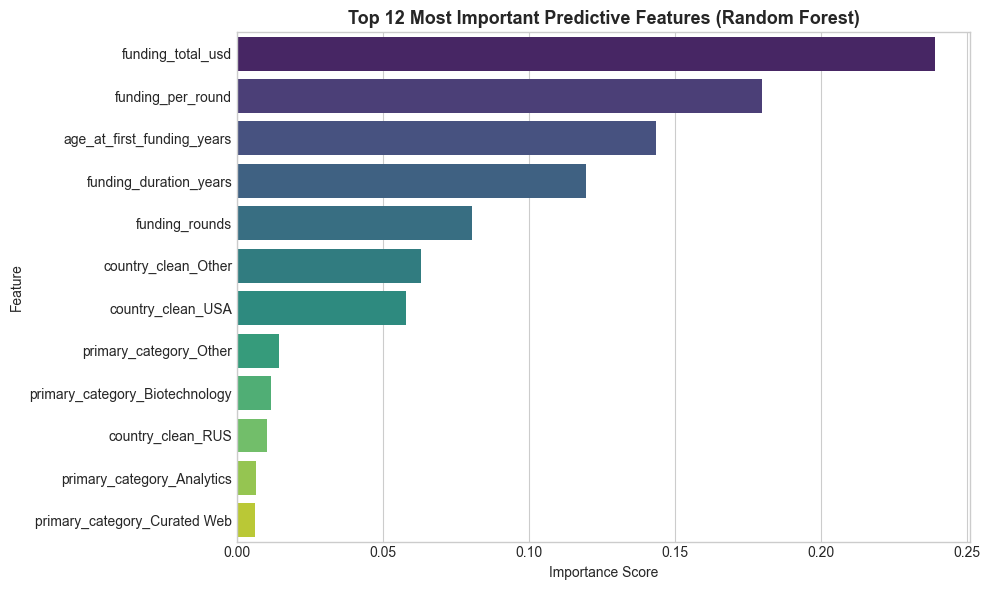

                       Feature  Importance
             funding_total_usd    0.239211
             funding_per_round    0.179742
    age_at_first_funding_years    0.143554
        funding_duration_years    0.119503
                funding_rounds    0.080647
           country_clean_Other    0.063119
             country_clean_USA    0.057892
        primary_category_Other    0.014466
primary_category_Biotechnology    0.011664
             country_clean_RUS    0.010332


In [9]:
best_clf = trained_models[best_model_name].named_steps['classifier']
preproc = trained_models[best_model_name].named_steps['preprocessor']

# Extract feature names from preprocessor
cat_encoder = preproc.named_transformers_['cat'].named_steps['encoder']
cat_feature_names = cat_encoder.get_feature_names_out(CATEGORICAL_FEATURES).tolist()
all_transformed_features = NUMERICAL_FEATURES + cat_feature_names

# Get importances
if hasattr(best_clf, 'feature_importances_'):
    importances = best_clf.feature_importances_
    feat_df = pd.DataFrame({
        'Feature': all_transformed_features,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=feat_df.head(12), x='Importance', y='Feature', palette='viridis')
    plt.title(f'Top 12 Most Important Predictive Features ({best_model_name})', fontsize=13, fontweight='bold')
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.show()

    print(feat_df.head(10).to_string(index=False))


---
## 8. 💾 Model Export for Backend Integration
Export the trained model pipeline (`startup_model.pkl`) and performance metadata (`metrics.json`) for consumption by the FastAPI backend.


In [10]:
export_dir = Path("backend/model")
export_dir.mkdir(parents=True, exist_ok=True)

model_path = export_dir / "startup_model.pkl"
metrics_path = export_dir / "metrics.json"

# Save best pipeline
joblib.dump(best_pipe, model_path)
print(f"✅ Saved best model ({best_model_name}) to: {model_path}")

# Save metrics JSON
export_metrics = {
    "best_model": best_model_name.lower().replace(" ", "_"),
    "models": {row['Model']: row for row in evaluation_results}
}

with open(metrics_path, "w") as f:
    json.dump(export_metrics, f, indent=2)

print(f"✅ Saved metrics summary to: {metrics_path}")


✅ Saved best model (Random Forest) to: backend\model\startup_model.pkl
✅ Saved metrics summary to: backend\model\metrics.json


---
## 9. 🧪 Interactive Sample Inference Test
Simulate scoring a new startup with the exported pipeline.


In [11]:
sample_startup = pd.DataFrame([{
    'funding_total_usd': 4500000.0,
    'funding_rounds': 3,
    'funding_duration_years': 2.5,
    'age_at_first_funding_years': 1.2,
    'funding_per_round': 1500000.0,
    'primary_category': 'Software',
    'country_clean': 'USA'
}])

loaded_pipeline = joblib.load(model_path)
prob_success = loaded_pipeline.predict_proba(sample_startup)[0, 1]
predicted_label = loaded_pipeline.predict(sample_startup)[0]

print("🚀 Prediction Result for Sample Startup:")
print(f"  • Success Probability : {prob_success * 100:.2f}%")
print(f"  • Failure Risk Score  : {(1 - prob_success) * 100:.2f}%")
print(f"  • Predicted Outcome   : {'Acquired / IPO (Success)' if predicted_label == 1 else 'Closed (High Risk)'}")


🚀 Prediction Result for Sample Startup:


  • Success Probability : 76.76%
  • Failure Risk Score  : 23.24%
  • Predicted Outcome   : Acquired / IPO (Success)
